# Transfer learning: Vision Transformer

Image classification: using google/vit-base-patch16-224 model from Hugging face hub


In [2]:
!pip install --quiet evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00


In [3]:
import io
from PIL import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from huggingface_hub import notebook_login
from datasets import load_dataset, DatasetDict

from transformers import AutoImageProcessor, ViTForImageClassification

from transformers import Trainer, TrainingArguments
import evaluate



In [ ]:
# login onto hugging face hub to load any private dataset/model.

notebook_login()


In [5]:
# load image classification dataset

dataset=load_dataset("pcuenq/oxford-pets")
dataset

dataset["train"][0]

README.md:   0%|          | 0.00/565 [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/1.10k [00:00<?, ?B/s]

data/train-00000-of-00001-ecc2afb43dedd5(…): reconstructing file:   0%|          |  0.00B /  234MB            

data/train-00000-of-00001-ecc2afb43dedd5(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/7390 [00:00<?, ? examples/s]

{'path': '/data/datasets/magic-ml/oxford-iiit-pet/images/Siamese_137.jpg',
 'label': 'Siamese',
 'dog': False,
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=345x500>}

In [6]:
dataset['train'][0]

{'path': '/data/datasets/magic-ml/oxford-iiit-pet/images/Siamese_137.jpg',
 'label': 'Siamese',
 'dog': False,
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=345x500>}

In [7]:
labels=dataset["train"].unique("label")
print(len(labels),labels)

37 ['Siamese', 'Birman', 'shiba inu', 'staffordshire bull terrier', 'basset hound', 'Bombay', 'japanese chin', 'chihuahua', 'german shorthaired', 'pomeranian', 'beagle', 'english cocker spaniel', 'american pit bull terrier', 'Ragdoll', 'Persian', 'Egyptian Mau', 'miniature pinscher', 'Sphynx', 'Maine Coon', 'keeshond', 'yorkshire terrier', 'havanese', 'leonberger', 'wheaten terrier', 'american bulldog', 'english setter', 'boxer', 'newfoundland', 'Bengal', 'samoyed', 'British Shorthair', 'great pyrenees', 'Abyssinian', 'pug', 'saint bernard', 'Russian Blue', 'scottish terrier']


In [8]:
type(dataset["train"][0]["image"])


PIL.JpegImagePlugin.JpegImageFile

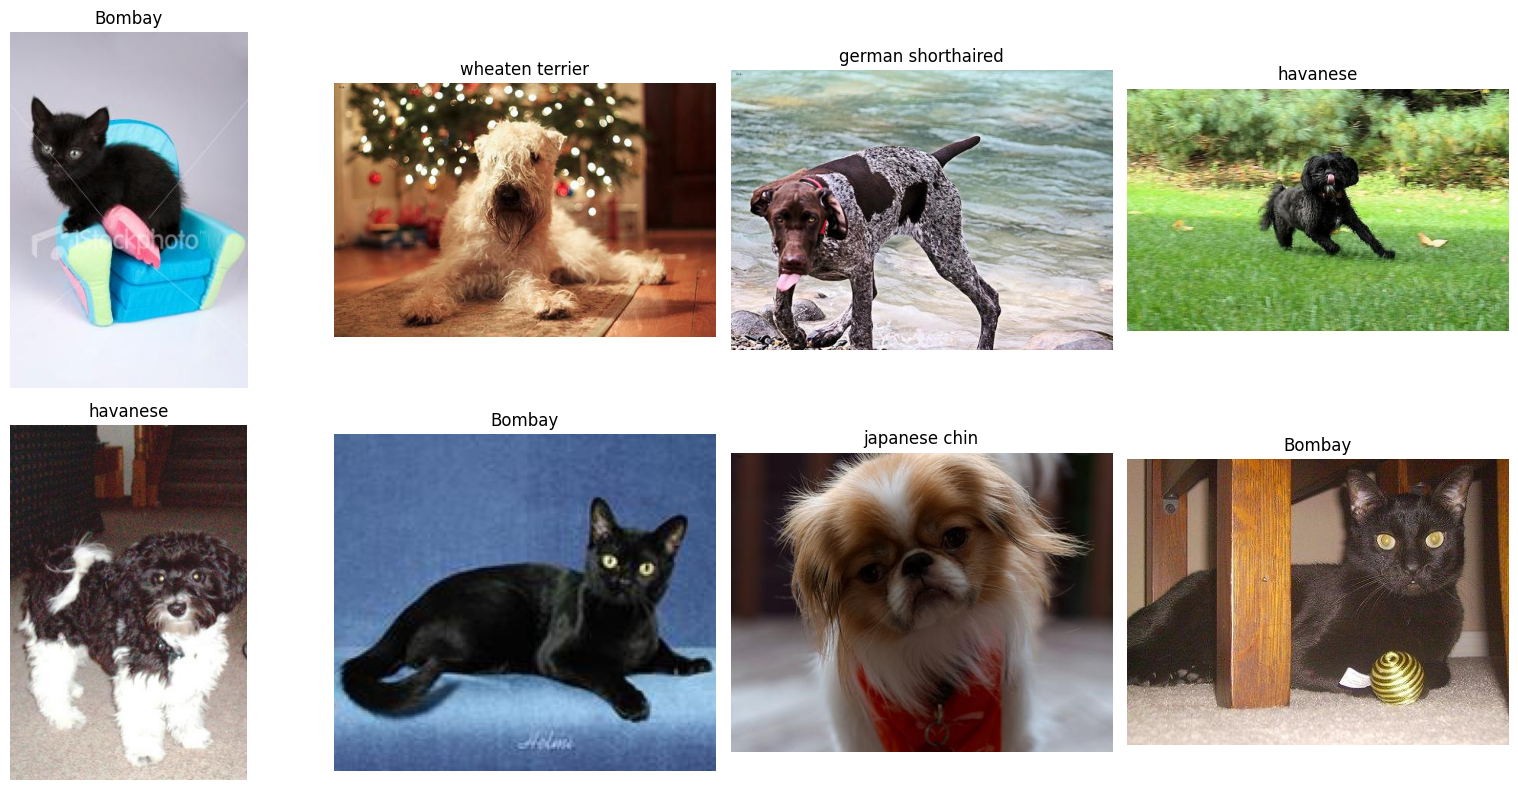

In [9]:
# see some sample image from dataset

def show_example(ds, rows, cols):
    samples = ds.shuffle(seed=42).select(range(rows * cols))

    plt.figure(figsize=(16, 8))

    for i in range(rows * cols):
        img = samples[i]["image"]
        label = samples[i]["label"]

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_example(dataset["train"],rows=2,cols=4)

In [10]:
# Preprocessing our dataset : image preprocessing involves resizing all image into same dimensions, normalizing and scale the pixel value to a uniform range, augmentation can be added like flips, rotations etc.
# before transformation, split dataset


split_dataset=dataset["train"].train_test_split(test_size=0.2)  #80% train, 20% eval
eval_dataset=split_dataset["test"].train_test_split(test_size=0.5) #50% evalutaion and 50% test

our_dataset=DatasetDict({
    "train":split_dataset["train"],
    "validation":eval_dataset["train"],
    "test":eval_dataset["test"]
})

our_dataset

DatasetDict({
    train: Dataset({
        features: ['path', 'label', 'dog', 'image'],
        num_rows: 5912
    })
    validation: Dataset({
        features: ['path', 'label', 'dog', 'image'],
        num_rows: 739
    })
    test: Dataset({
        features: ['path', 'label', 'dog', 'image'],
        num_rows: 739
    })
})

In [11]:
# we will create mapping since model cant understand label in string. We map them to their integer counterparts. label2id and id2label to convert the labels to their IDs and vice versa.

label2id={c:idx for idx,c in enumerate(labels)}
id2label={idx:c for idx,c in enumerate(labels)}

In [12]:
# Image processor : By AutoImageProcessor

processor= AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
processor



preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

```

Prepare each batch of images before training.
Make sure all images are in RGB format, even if some are grayscale or transparent.
Turn text labels into numbers so the model can understand them.
Use the processor to resize/transform the images and convert them into a format PyTorch can use.
The final data given to the model will contain:
pixel_values → the processed images
labels → the numerical labels
with_transform() connects this preprocessing function to the dataset, so it happens automatically when the trainer needs the data.

In short: with_transform() makes sure every batch is automatically cleaned, labeled, and converted into the right format before the model trains on it.

```

In [14]:
def transforms(batch):
    images = [x.convert("RGB") for x in batch["image"]]

    inputs = processor(images, return_tensors="pt")

    inputs["labels"] = [label2id[y] for y in batch["label"]]

    return inputs




In [15]:
processed_dataset=our_dataset.with_transform(transforms)

In [16]:
# Data collation:

def collate_fn(batch):
  return{
      "pixel_values":torch.stack([x["pixel_values"] for x in batch]),
      "labels":torch.tensor([x["labels"]for x in batch])
  }

In [30]:
# evaluate the metrics by hugging face evaluate library

import numpy as np
import evaluate

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_preds):
    logits, labels = eval_preds

    print("LOGITS:", type(logits), getattr(logits, "shape", None))
    print("LABELS:", type(labels), getattr(labels, "shape", None))

    predictions = np.argmax(logits, axis=1)

    return accuracy.compute(
        predictions=predictions,
        references=labels
    )


In [31]:
model=ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

[transformers] You passed `num_labels=37` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([37, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([37])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [32]:
# architecture of model
model

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

In [33]:


for name, p in model.named_parameters():
  if not name.startswith("classifier"):
    p.requires_grad=False

In [34]:
num_params = sum([p.numel() for p in model.parameters()])
trainable_params = sum([p.numel() for p in model.parameters() if p.requires_grad])

print(f"{num_params = :,} | {trainable_params = :,}")

num_params = 85,827,109 | trainable_params = 28,453


In [35]:
# Training our model with hugging face

training_args = TrainingArguments(
    output_dir="./vit-base-oxford-iiit-pets",
    per_device_train_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,
    num_train_epochs=5,
    learning_rate=3e-4,
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to='tensorboard',
    load_best_model_at_end=True,
)

In [36]:
trainer=Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=processed_dataset["train"],
    eval_dataset=processed_dataset["validation"],
    processing_class=processor,
)

In [37]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.401413,0.278033,0.933694
2,0.208449,0.218384,0.936401
3,0.166808,0.196081,0.936401
4,0.138991,0.190119,0.941813
5,0.129088,0.188726,0.941813


LOGITS: <class 'numpy.ndarray'> (739, 37)
LABELS: <class 'numpy.ndarray'> (739,)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

LOGITS: <class 'numpy.ndarray'> (739, 37)
LABELS: <class 'numpy.ndarray'> (739,)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

LOGITS: <class 'numpy.ndarray'> (739, 37)
LABELS: <class 'numpy.ndarray'> (739,)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before

TrainOutput(global_step=1850, training_loss=0.3122928335859969, metrics={'train_runtime': 527.7948, 'train_samples_per_second': 56.007, 'train_steps_per_second': 3.505, 'total_flos': 2.2913817801515827e+18, 'train_loss': 0.3122928335859969, 'epoch': 5.0})

In [38]:
# evaluate on test dataset

trainer.evaluate(processed_dataset["test"])

LOGITS: <class 'numpy.ndarray'> (739, 37)
LABELS: <class 'numpy.ndarray'> (739,)


Training Loss,Validation Loss,Epoch,Accuracy
0.129088,0.217690,5,0.933694


{'eval_loss': 0.21769002079963684, 'eval_accuracy': 0.9336941813261164}

In [39]:
# predictions
def show_predictions(rows, cols):
    samples = our_dataset["test"].shuffle(seed=42).select(range(rows * cols))
    processed_samples = samples.with_transform(transforms)

    predictions = trainer.predict(processed_samples).predictions.argmax(axis=1)

    fig = plt.figure(figsize=(cols * 4, rows * 4))

    for i in range(rows * cols):
        img = samples[i]["image"]

        prediction = predictions[i]

        label = (
            f"label: {samples[i]['label']}\n"
            f"predicted: {id2label[prediction]}"
        )

        fig.add_subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_predictions(rows=5, cols=5)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# optional

kwargs = {
    "finetuned_from": model.config._name_or_path,
    "dataset": 'pcuenq/oxford-pets',
    "tasks": "image-classification",
    "tags": ['image-classification'],
}